## Clusterizaciòn de codificaciones

## Importación de librerias necesarias

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
from pyspark.sql import functions as F, types as T, DataFrame, Window
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.cluster import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import array_to_vector
from src.gold.training.pca import PCAEncoder

In [4]:
from src.utils.spark import SparkUtils
spark_utils = SparkUtils('clusterize_encodings')
spark = spark_utils.spark

:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f6aaadfb-1208-455d-93d9-a24202d63a43;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 136ms :: artifacts dl 5ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

In [5]:
REGENERATE_INTERMEDIATE_TABLES = False

In [6]:
GOLD_SCHEMA = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
GOLD_SCHEMA_ENCODING = 'gold.encoding'
SCHEMA = 'silver.preprocess'

## Cargar información de codificaciones

In [42]:
main_category_encoded = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded', catalog = GOLD_SCHEMA
))

meta_items = spark.read.format('delta').load(spark_utils.path('meta_items', 'bronze'))

reviews_indexed = spark.read.format('delta').load(spark_utils.path(
    'reviews_indexed', catalog = SCHEMA
))

df_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca', catalog = GOLD_SCHEMA
))

df_vectorized_pca_balanced = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_balanced', catalog = GOLD_SCHEMA
))

df_vectorized_pca_minillm = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca_minillm', catalog = GOLD_SCHEMA
))

In [43]:
reviews_indexed.show(1)

+--------------------+--------------------+-----------+------+------------+--------------+---------+
|               title|                text|parent_asin|rating|helpful_vote|rating_boolean|review_id|
+--------------------+--------------------+-----------+------+------------+--------------+---------+
|Card is out of da...|I purchased this ...| B00003006R|   1.0|           1|             0|       45|
+--------------------+--------------------+-----------+------+------------+--------------+---------+
only showing top 1 row



Definir conjunto de embebido a probar

In [8]:
df_items_features = df_vectorized_pca_balanced.select(
    "parent_asin", F.col("pca_features").alias("features")
)

df_items_features_minillm = df_vectorized_pca_minillm.select(
    "parent_asin", F.col("pca_features").alias("features")
)

## Clusterización K-Means

### Caso promediado sin distinción

In [9]:
from src.utils.models.clustering.KMeansClustering import KMeansClustering, KMeansParameter
from src.utils.visualization.clustering import plot_cluster_distribution

In [10]:
kmeans_clustering = KMeansClustering(
    k_parameters=[
        KMeansParameter(comb_id="pca_features_1000_300", n_clusters=1000, max_iter=300, random_state=42),
        KMeansParameter(comb_id="pca_features_2000_300", n_clusters=2000, max_iter=300, random_state=42)
    ],
    spark_utils=spark_utils,
    table_prefix="kmeans_pca_features",
    catalog=GOLD_SCHEMA_CLUSTER,
    id_col="parent_asin",
    features_col="features",
    prediction_col="cluster"
)

In [11]:
if REGENERATE_INTERMEDIATE_TABLES:
    kmeans_clustering.fit(df_items_features)
    evaluations = kmeans_clustering.evaluate()
    print(evaluations)

In [12]:
CHOSEN_COMB_ID = "pca_features_2000_300"
kmeans_clustering.load(CHOSEN_COMB_ID)
kmeans_meta_items_clustered = kmeans_clustering.transform(df_items_features)

00:00:30.202 [Executor task launch worker for task 1.0 in stage 16.0 (TID 115)] ERROR org.apache.spark.executor.Executor - Exception in task 1.0 in stage 16.0 (TID 115)
org.apache.spark.SparkException: [FAILED_EXECUTE_UDF] Failed to execute user defined function (`KMeansModel$$Lambda$3748/0x00000008416b0840`: (struct<type:tinyint,size:int,indices:array<int>,values:array<double>>) => int).
	at org.apache.spark.sql.errors.QueryExecutionErrors$.failedExecuteUserDefinedFunctionError(QueryExecutionErrors.scala:198) ~[spark-catalyst_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.sql.errors.QueryExecutionErrors.failedExecuteUserDefinedFunctionError(QueryExecutionErrors.scala) ~[spark-catalyst_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.processNext(Unknown Source) ~[?:?]
	at org.apache.spark.sql.execution.BufferedRowIterator.hasNext(BufferedRowIterator.java:43) ~[spark-sql_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.sql.execut

Py4JJavaError: An error occurred while calling o143.save.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 16.0 failed 1 times, most recent failure: Lost task 1.0 in stage 16.0 (TID 115) (192.168.1.33 executor driver): org.apache.spark.SparkException: [FAILED_EXECUTE_UDF] Failed to execute user defined function (`KMeansModel$$Lambda$3748/0x00000008416b0840`: (struct<type:tinyint,size:int,indices:array<int>,values:array<double>>) => int).
	at org.apache.spark.sql.errors.QueryExecutionErrors$.failedExecuteUserDefinedFunctionError(QueryExecutionErrors.scala:198)
	at org.apache.spark.sql.errors.QueryExecutionErrors.failedExecuteUserDefinedFunctionError(QueryExecutionErrors.scala)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.processNext(Unknown Source)
	at org.apache.spark.sql.execution.BufferedRowIterator.hasNext(BufferedRowIterator.java:43)
	at org.apache.spark.sql.execution.WholeStageCodegenEvaluatorFac

In [ ]:
kmeans_clustering.evaluate_current(df_items_features, kmeans_meta_items_clustered)

0.02674036939047665

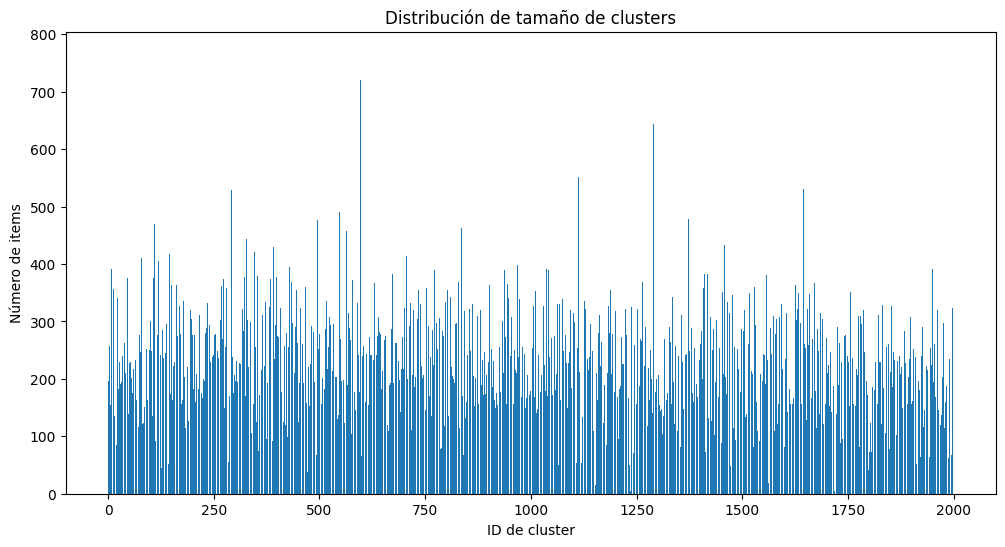

In [ ]:
plot_cluster_distribution(
    kmeans_meta_items_clustered, 'cluster'
)

## Muestreo de datos para clusterización

In [25]:
main_category_columns = [col for col in main_category_encoded.columns if col.startswith('main_category_')]

df_with_categories = df_vectorized_pca.join(
    main_category_encoded.select('parent_asin', *main_category_columns),
    on='parent_asin',
    how='inner'
)

samples_per_class = []
for category_col in main_category_columns:
    category_samples = (
        df_with_categories
        .filter(F.col(category_col) == 1)
        .sample(1.0, seed=42)
        .limit(10_000)
    )
    samples_per_class.append(category_samples)

df_weighted_sample = samples_per_class[0]
for sample_df in samples_per_class[1:]:
    df_weighted_sample = df_weighted_sample.union(sample_df)


In [26]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        df_weighted_sample.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('df_weighted_sample', catalog=GOLD_SCHEMA_CLUSTER))
    )

df_weighted_sample = spark.read.format('delta').load(spark_utils.path(
    'df_weighted_sample', catalog=GOLD_SCHEMA_CLUSTER
))

In [27]:
df_weighted_sample.count()

74200

## LSH based

### Ejecución hallazgo de vecinos mas cercanos

In [9]:
MIN_COSINE_SIMMILARITY = 0.9
NUM_NEIGHBORS = 10

In [34]:
from src.utils.models.clustering.LSHNeighborsClustering import LSHNeighborsClustering, LSHNeighborsClusteringParameter

lsh_clustering = LSHNeighborsClustering(
    lsh_parameters=LSHNeighborsClusteringParameter(
        comb_id="pca_features_1000_300",
        n_neighbors=NUM_NEIGHBORS,
        min_cosine_similarity=MIN_COSINE_SIMMILARITY,
        bucket_length=1.0,
        num_hash_tables=5
    ),
    spark_utils=spark_utils,
    table_prefix="lsh_pca_features_balanced",
    catalog=GOLD_SCHEMA_CLUSTER,
    id_col="parent_asin",
    features_col="features",
    hashes_col="hashes",
    batch_size=10_000
)

In [35]:
if REGENERATE_INTERMEDIATE_TABLES:
    lsh_clustering.prepare_batching(df_items_features)
lsh_clustering.load_batching()

DataFrame[parent_asin: string, batch_idx: bigint]

In [36]:
if REGENERATE_INTERMEDIATE_TABLES:
    lsh_clustering.prepare_possible_batch_pairs()
lsh_clustering.load_possible_batch_pairs()

DataFrame[batch_idx_a: int, batch_idx_b: int]

In [37]:
if REGENERATE_INTERMEDIATE_TABLES:
    lsh_clustering.fit(df_items_features)
    lsh_clustering.find_pairs(
        df_items_features,
        overwrite_full=True
    )

## Pruebas agrupación

In [38]:
pairs = spark.read.format('delta').load( lsh_clustering.pairs_path )


In [39]:
pairs.count()

17:06:52.266 [Thread-4] ERROR org.apache.spark.sql.delta.util.NonFateSharingFuture - Failed to get result from future
scala.runtime.NonLocalReturnControl: null


69357

In [20]:
pairs.filter(F.col('parent_asin_a') == "B074JLV5XX").show(20)

+-------------+-------------+------------------+
|parent_asin_a|parent_asin_b|        cosine_sim|
+-------------+-------------+------------------+
|   B074JLV5XX|   B075ZDFYDY|0.9411782838076508|
|   B074JLV5XX|   B07Q5VKF1G|0.9462786325966811|
|   B074JLV5XX|   B078B9RGR8| 0.952629702696235|
|   B074JLV5XX|   B07PLMT6Y2| 0.939043889033465|
|   B074JLV5XX|   B08B9XFWT1|0.9045908933375996|
|   B074JLV5XX|   B08G8ZFVLM| 0.952977954014717|
|   B074JLV5XX|   B07VWSDPSN|0.9428793011636314|
|   B074JLV5XX|   B07VZWJGS7|0.9062022470757471|
|   B074JLV5XX|   B08GF1HZKJ|0.9465701004643476|
|   B074JLV5XX|   B08713GYDZ| 0.929996829606414|
|   B074JLV5XX|   B081B9CQ46| 0.943887666910909|
+-------------+-------------+------------------+



In [40]:
meta_items.filter(F.col('parent_asin') == "B08B9XFWT1").toPandas().to_dict()

{'title': {0: 'HumanCentric VESA Mount Adapter Compatible with Dell Monitors, VESA Adapter for Monitor SE2416HX, SE2717HX, SE2717HR, SE2717H, S2216M, S2216H, SE2716H, SE2216H, SE2417HG, SE2416H, S2216H, and More'},
 'main_category': {0: 'Office Products'},
 'features': {0: ['Only fits select Dell S and SE series monitors: This VESA adapter bracket is tested and guaranteed to work with Dell S2216H, S2216HV, S2216M, S2316H, S2316M, S2317HJ, S2416H, S2717Q, S2817Q, SE2216H, SE2216HM, SE2216HV, SE2416H, SE2416HSC1, SE2416HX, SE2417HG, SE2716H, SE2717H, SE2717HR, SE2717HX, SE2417HGX, and SE2717HC.',
   'Model number warning: If the fourth digit in your model number is an 8 or a 9 (ex. 2418, 2219, etc.), this VESA adapter bracket will not work. Refer to the chart below to find the correct model for your Dell monitor mounts. Check your model number very carefully!',
   'Easy Installation: You’ll be able to install HumanCentric Dell monitor bracket in less than two minutes with nothing more th

In [16]:
meta_items.filter(F.col('parent_asin') == "B074JLV5XX").toPandas().to_dict()

{'title': {0: 'VESA Mount Adapter for Dell S2218, S2318, S2319, S2418, S2419, S2718, S2719 Monitors | Does Not Fit Ultrathin Monitors S2718D, S2719HM, and S2719DM | [Patented] - by HumanCentric'},
 'main_category': {0: 'Office Products'},
 'features': {0: ['FITS SELECT DELL S-SERIES MONITORS: This bracket is tested and guaranteed to work with: Dell S2218H, S2318HX, S2318HN, S2318NX, S2319H, S2319HN, S2418HX, S2418HN, S2418NX, S2419H, S2419HN, S2718HX, S2718HN, S2718NX, S2719H, and S2719HN (Does not fit any Ultrathin monitors such as S2718D, S2419HM and S2719DM)',
   'IMPORTANT NOTE: Does not fit the SE2219H, SE2419H, and SE2719H - Please select the size labeled "Dell S2*18, S2*19, and SE2*19 (Not Ultrathin Models)" for the VESA adapter for those model numbers',
   'MOUNT YOUR DELL MONITOR ON A STANDARD VESA MOUNT - Even though these monitors weren’t made with mounting holes, our convenient bracket enables you to connect your Dell monitor anyway! Whether you’re looking to mount it on th

In [23]:
(
    pairs.groupBy('parent_asin_a')
        .agg(F.count('*').alias('count'))
        .filter(F.col('count') > 10)
        .orderBy('count', ascending=False).show()
)

+-------------+-----+
|parent_asin_a|count|
+-------------+-----+
|   B09JNWHXWW|  132|
|   B008I65B8Y|  110|
|   B008I6430Q|  110|
|   B008I63BZ4|  110|
|   B008I64UX6|  110|
|   B00FBIZR4U|  110|
|   B005STXRPI|  110|
|   B00FBJ4G82|  110|
|   B00FBJA6QS|  110|
|   B008I62AYC|  110|
|   B008I639UQ|  110|
|   B008I641KS|  110|
|   B008I64NB0|  110|
|   B008I64MAC|  110|
|   B008I63C9O|  110|
|   B00FBJ460K|  110|
|   B008I63K00|  110|
|   B008I63CTO|  110|
|   B008I63JS8|  110|
|   B008I63REY|  110|
+-------------+-----+
only showing top 20 rows



In [60]:
meta_items.filter(F.col('main_category') == F.lit('Computers')).count()

444322

In [24]:
pairs.filter(F.col('parent_asin_a') == "B09JNWHXWW").show()

+-------------+-------------+------------------+
|parent_asin_a|parent_asin_b|        cosine_sim|
+-------------+-------------+------------------+
|   B09JNWHXWW|   B09GG44PXR| 0.931829471970991|
|   B09JNWHXWW|   B0B743QR7T|0.9051063748384647|
|   B09JNWHXWW|   B09J2BMSSL|0.9029107100138709|
|   B09JNWHXWW|   B09WRF3C8K|0.9441044620580835|
|   B09JNWHXWW|   B09NVJKK3B|0.9055025750666184|
|   B09JNWHXWW|   B09Y63XNR3|0.9053854904992825|
|   B09JNWHXWW|   B098N8PBWG|0.9096501620387906|
|   B09JNWHXWW|   B0B14LH7BS|0.9047262525203075|
|   B09JNWHXWW|   B0B41J6HK3|0.9202711952666911|
|   B09JNWHXWW|   B09DGDVDQL|0.9275403241681206|
|   B09JNWHXWW|   B0BG5N2BP1|0.9177163646093404|
|   B09JNWHXWW|   B09ZFB8SL5|0.9150768252382715|
|   B09JNWHXWW|   B0B3VQF33X|0.9220218181668001|
|   B09JNWHXWW|   B09MYN51N5|0.9132612446884449|
|   B09JNWHXWW|   B09SLTR62D| 0.951469286141775|
|   B09JNWHXWW|   B09S5ML6WC|0.9363251265907286|
|   B09JNWHXWW|   B0924M5YTR|0.9160840482268032|
|   B09JNWHXWW|   B0

In [52]:
a = reviews_indexed.filter(F.col('parent_asin') == "B0BG715FY1").toPandas()

In [53]:
len(a)

24

In [33]:
meta_items.filter(F.col('parent_asin') == "B0BG715FY1").toPandas().to_dict()

{'title': {0: 'Apple MFi Certified iPhone Charger,2 Set 3.3FT Lightning Cable with USB Plug Fast Charging Cube High Speed Data Sync USB Cable Compatible with iPhone 11/12/13 Pro Max/XS/XR/X/8/7/Plus/6S/SE/iPad'},
 'main_category': {0: 'Industrial & Scientific'},
 'features': {0: ['[Safe & Fast Charger] iPhone charger set approved by the U.S. Safe Market. This iPhone charger brick Multiple built-in safeguards and intelligent IC identification technology protect against short circuit, over-current, over-voltage, over-heating and over-charging.',
   '[2 Sets iPhone Charger Cube with Cord] 2 Pack iPhone wall charger block for your convenience, Lightweight, compact design that fits your storage requirements. You can take it when you travel, The iPhone Charger is ideal for charging at home or in the office or travel outside, which is lightweight in weight and small in size.',
   '[Apple Certified Lightning Cable] MFi Certified iPhone Lightning Charger Cord built in an original chip, which me

In [30]:
meta_items.filter(F.col('parent_asin') == "B0B41J6HK3").toPandas().to_dict()

{'title': {0: 'OuTrade iPhone Charger Cable, 3 Pack MFi Lightning Cable Durable Braided Fast Charging Cord Compatible for iPhone SE 12 11 11 Pro 11 Pro Max Xs MAX XR X 8 7 6S 6, iPad and More (Black, 10 ft)'},
 'main_category': {0: 'Industrial & Scientific'},
 'features': {0: ['【MFi Certified Lightning Cable】 Built with original MFi chip promise no warning message pops up, ensured safe fast charging and data transfer for your devices',
   '【2.4A Fast Charging & 480Mbps Data Transfer】 High-quality four-core copper wires enhance charging & data transfer speed of the iPhone cables. Built-In MFi Certified chipset ensures a faster charging time while keeping your device completely safe',
   '【Premium Durable Braided Material】 iPhone cord with laser welding technology that have passed 50,000+ times bending tests for extra protection and durability. Braided insulation and precisely layer-welded connectors, which make cable more durable and sturdier than normal iPhone charger cables but also f

In [28]:
main_category_encoded.columns

['title',
 'main_category',
 'features',
 'description',
 'average_rating',
 'rating_number',
 'price',
 'store',
 'parent_asin',
 'categories',
 'details',
 'images',
 'description_colapsed',
 'features_colapsed',
 'colapsed_text',
 'colapsed_text_spelled',
 'colapsed_text_words',
 'colapsed_text_length',
 'review_count',
 'main_category_computers',
 'main_category_all_electronics',
 'main_category_home_audio_theater',
 'main_category_amazon_home',
 'main_category_industrial_scientific',
 'main_category_cell_phones_accessories',
 'main_category_car_electronics',
 'main_category_office_products',
 'main_category_camera_photo']

### Ejecución hallazgo de vecinos mas cercanos (miniLLM)

In [61]:
MIN_COSINE_SIMMILARITY = 0.9
NUM_NEIGHBORS = 10

In [62]:
from src.utils.models.clustering.LSHNeighborsClustering import LSHNeighborsClustering, LSHNeighborsClusteringParameter

lsh_clustering_minillm = LSHNeighborsClustering(
    lsh_parameters=LSHNeighborsClusteringParameter(
        comb_id="pca_features_1000_300",
        n_neighbors=10,
        min_cosine_similarity=MIN_COSINE_SIMMILARITY,
        bucket_length=1.0,
        num_hash_tables=5
    ),
    spark_utils=spark_utils,
    table_prefix="lsh_pca_features_minillm",
    catalog=GOLD_SCHEMA_CLUSTER,
    id_col="parent_asin",
    features_col="features",
    hashes_col="hashes",
    batch_size=10_000
)

In [24]:
if True:
    lsh_clustering_minillm.prepare_batching(df_items_features_minillm)
lsh_clustering_minillm.load_batching()

DataFrame[parent_asin: string, batch_idx: bigint]

In [25]:
if True:
    lsh_clustering_minillm.prepare_possible_batch_pairs()
lsh_clustering_minillm.load_possible_batch_pairs()

[INFO] Total batches: 44
[INFO] Total possible batch pairs: 990


DataFrame[batch_idx_a: int, batch_idx_b: int]

In [26]:
target_pairs = spark.read.format('delta').load(spark_utils.path(
    f"lsh_pairs_possible_batch_pairs_{lsh_clustering_minillm.table_prefix}_{lsh_clustering_minillm.lsh_parameters.comb_id}",
    catalog = lsh_clustering_minillm.catalog
))

In [ ]:
processed_target_path = spark.read.format('delta').load(spark_utils.path(
    f"lsh_pairs_processed_{lsh_clustering_minillm.table_prefix}_{lsh_clustering_minillm.lsh_parameters.comb_id}",
    catalog = lsh_clustering_minillm.catalog
))

In [ ]:
if True:
    lsh_clustering_minillm.fit(df_items_features_minillm)
    lsh_clustering_minillm.find_pairs(
        df_items_features_minillm,
        overwrite_full=False
    )

In [74]:
pairs = spark.read.format('delta').load(spark_utils.path(
    'lsh_pairs_lsh_pca_features_minillm_pca_features_1000_300', catalog=GOLD_SCHEMA_CLUSTER
))


In [75]:
pairs_minillm = pairs

In [89]:
pairs_minillm.filter(F.col('parent_asin_a') == "B000NNS5XS").count()

1

In [13]:
pairs_use.filter(F.col('parent_asin_a') == "B000NNS5XS").count()

11:12:23.690 [Thread-4] ERROR org.apache.spark.sql.delta.util.NonFateSharingFuture - Failed to get result from future
scala.runtime.NonLocalReturnControl: null


12

In [80]:
pairs_use.alias('A').join(
    pairs_minillm.alias('B'), on='parent_asin_a', how='inner'
).select('A.parent_asin_a').distinct().show()

+-------------+
|parent_asin_a|
+-------------+
|   B0011FTKFY|
|   B00123V6PW|
|   B000H7GVA4|
|   B000UTIB7A|
|   B000NNS5XS|
|   B000UHDRAS|
|   B000VEPC6W|
|   B000X1OGGU|
|   B000IEAYN6|
|   B000EZKAHO|
|   B000ZJQO6A|
|   B000VABPAI|
|   B0012MULLI|
|   B000II0AKO|
|   B000SDW84K|
|   B000N8HX90|
|   B00126MAHW|
|   B000WWQJ88|
|   B000NOUP0S|
|   B000IJKHU6|
+-------------+
only showing top 20 rows



In [65]:
(
    pairs.groupBy('parent_asin_a')
        .agg(F.count('*').alias('count'))
        .filter(F.col('count') > 10)
        .orderBy('count', ascending=True).show()
)

+-------------+-----+
|parent_asin_a|count|
+-------------+-----+
|   B000GX47R8|   11|
|   B000ELG8PG|   11|
|   B00113V748|   11|
|   B000O8WE66|   11|
|   B000XRQ2Q6|   11|
|   B000YE8SAQ|   11|
|   B000SR0690|   11|
|   B0012OI6HW|   11|
|   B000V1SUQE|   11|
|   B000IEFILY|   11|
|   B000SNP0RW|   11|
|   B000F1WBUG|   11|
|   B000ENOSQ0|   11|
|   B000EYFFDY|   11|
|   B000W8U4GK|   11|
|   B000W9DO7U|   11|
|   B000LZCIXQ|   11|
|   B000EP5MQI|   11|
|   B000CDA7US|   11|
|   B0012OKAP8|   11|
+-------------+-----+
only showing top 20 rows



In [14]:
pairs_use.filter(F.col('parent_asin_a') == "B000NNS5XS").show()

+-------------+-------------+------------------+
|parent_asin_a|parent_asin_b|        cosine_sim|
+-------------+-------------+------------------+
|   B000NNS5XS|   B0011ZCDKS| 0.918802649577544|
|   B000NNS5XS|   B000V1XLNG|0.9217574779281436|
|   B000NNS5XS|   B000HAOVGM|0.9240184806842342|
|   B000NNS5XS|   B000Q30420|0.9141726918912301|
|   B000NNS5XS|   B000OSLLPG|0.9801362033890302|
|   B000NNS5XS|   B000V1VG2E|0.9456833395616066|
|   B000NNS5XS|   B001IKKDKS|0.9044325495609654|
|   B000NNS5XS|   B001T9NUQM|0.9027998741503909|
|   B000NNS5XS|   B001G60DXG|0.9003039326496802|
|   B000NNS5XS|   B0012YA4YK|0.9023817854068865|
|   B000NNS5XS|   B001SER4AG|0.9012627772070566|
|   B000NNS5XS|   B001G60DWM|0.9053921046899697|
+-------------+-------------+------------------+



In [91]:
pairs_minillm.filter(F.col('parent_asin_a') == "B000NNS5XS").show()

+-------------+-------------+------------------+
|parent_asin_a|parent_asin_b|        cosine_sim|
+-------------+-------------+------------------+
|   B000NNS5XS|   B0036RH3T0|0.9357998889528806|
+-------------+-------------+------------------+



In [92]:
meta_items.filter(F.col('parent_asin') == "B000NNS5XS").toPandas().to_dict()

{'title': {0: 'Canon PowerShot SD1000 7.1MP Digital Elph Camera with 3x Optical Zoom (Black) (OLD MODEL)'},
 'main_category': {0: 'Camera & Photo'},
 'features': {0: ['7.1-megapixel CCD captures enough detail for photo-quality 15 x 20-inch prints',
   '3x optical zoom; ISO 1600 and High ISO Auto',
   'DIGIC III Image Processor; Face Detection AF/AE',
   'Selectable shooting modes and special scene modes',
   'Print/Share button makes direct printing simple']},
 'description': {0: ['Product Description',
   'Canon PowerShot SD1000 7.1MP Digital Elph Camera with 3x Optical Zoom (Black)',
   'From the Manufacturer',
   'Canon looked to the very first Elph for inspiration when designing the PowerShot SD1000 Digital Elph, and came up with a quintessential iteration of the icon: slim, clean-lined and fully flat. Inside, the SD1000 Digital Elph looks only to the future: 7.1 megapixels, a 3x optical zoom and advanced DIGIC III ensure top-quality images, while focus is fast and sharp and red-ey

In [99]:
meta_items.filter(F.col('parent_asin') == "B0036RH3T0").toPandas().to_dict()

{'title': {0: 'NETGEAR Digital Entertainer Express (EVA9100)'},
 'main_category': {0: 'All Electronics'},
 'features': {0: ['Plays video, MP3s and digital photos from your PC, Mac or network attached storage device (NAS) to your HDTV',
   'Browse and play popular movies and TV shows from Hulu, Netflix, CBS, and more using PlayOn on your PC (free trial and special discountº)',
   'Automatically finds all digital media files on your home network and organizes them into an easily accessible library',
   'Includes one HDMI port, HD upconversion up to 1080p, and two USB ports for iPod and USB drives',
   'Easily add a NETGEAR Wireless USB Adapter (EVAW111) to connect wirelessly']},
 'description': {0: ['Product Description',
   'Why NETGEAR’s Digital Entertainer Express (EVA9100)? Plays video, MP3s and digital photos from your PC, Mac or network attached storage device (NAS) to your HDTV, Browse and play popular movies and TV shows from Hulu, Netflix, CBS, and more using PlayOn on your PC (

## Hierarchical Clustering with Cosine Similarity


In [38]:
REGENERATE_HIERARCHICAL = False
N_CLUSTERS_HIERARCHICAL = 150

In [39]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering

if REGENERATE_HIERARCHICAL:
    pdf = df_weighted_sample.select("parent_asin", "pca_features").toPandas()
    embeddings = np.vstack(pdf["pca_features"].values)

    model = AgglomerativeClustering(
        linkage='average',
        n_clusters=None,
        distance_threshold=0.5,
        metric='cosine'
    )

    labels = model.fit_predict(embeddings)
    pdf["cluster_hierarchical"] = labels
    sample_equitative_hierarchical = spark.createDataFrame(pdf)

    (
        sample_equitative_hierarchical.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('sample_equitative_hierarchical', catalog=GOLD_SCHEMA_CLUSTER))
    )

sample_equitative_hierarchical = spark.read.format('delta').load(spark_utils.path(
    'sample_equitative_hierarchical', catalog=GOLD_SCHEMA_CLUSTER
))

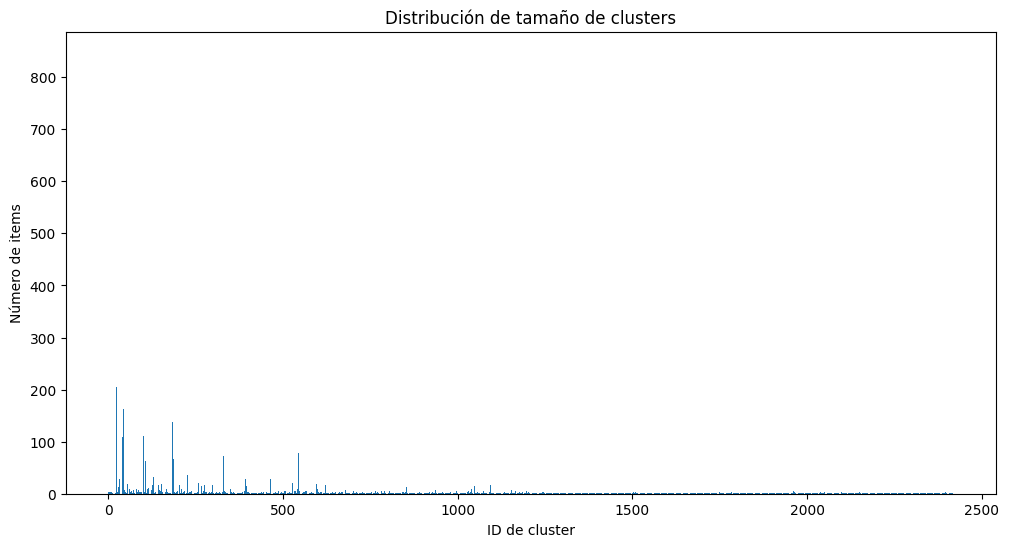

In [40]:
plot_cluster_distribution(
    sample_equitative_hierarchical, 'cluster_hierarchical'
)

In [41]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

## DBScan Clustering with Cosine Similarity


In [42]:
def hdbscan_partition(iterator):
    import numpy as np
    import hdbscan
    data = np.array([x for x in iterator])
    if len(data) == 0:
        return iter([])
    model = hdbscan.HDBSCAN(min_cluster_size=2)
    labels = model.fit_predict(data)
    return iter([(data[i].tolist(), int(labels[i])) for i in range(len(labels))])

In [43]:
if REGENERATE_INTERMEDIATE_TABLES:
    result_rdd = df_items_features.select("features").rdd.map(lambda r: r.features.toArray()).mapPartitions(hdbscan_partition)
    result_df = result_rdd.toDF(["features", "cluster"])
    
    (
        result_df.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('dbscan_meta_items_clustered_equi', catalog=GOLD_SCHEMA_CLUSTER))
    )

dbscan_meta_items_clustered_equi = spark.read.format('delta').load(spark_utils.path(
    'dbscan_meta_items_clustered_equi', catalog=GOLD_SCHEMA_CLUSTER
))

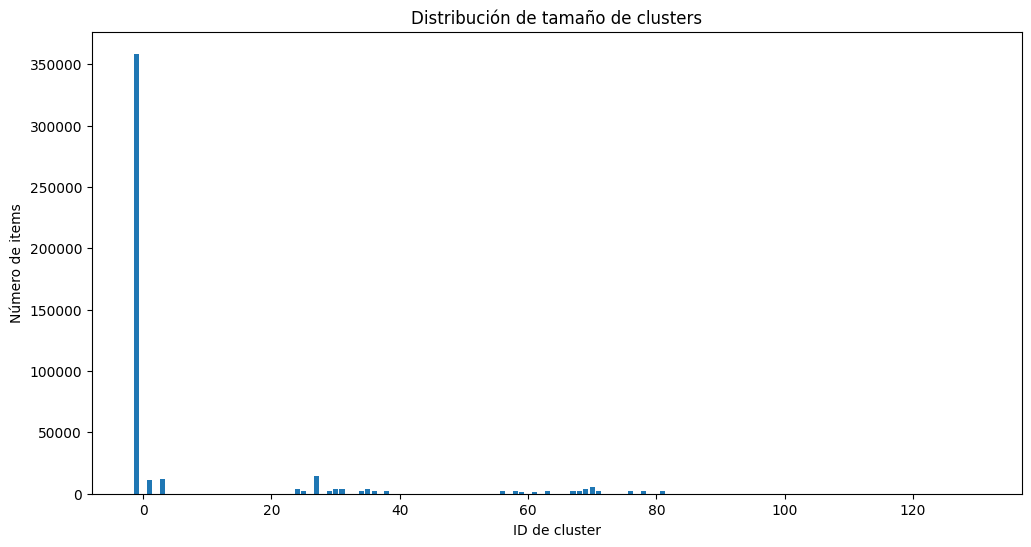

In [44]:
plot_cluster_distribution(
    dbscan_meta_items_clustered_equi, 'cluster'
)

## ECSAGO Algorithm Implementation


In [45]:
from src.utils.models.ecsago import ECSAGO

In [46]:
if REGENERATE_INTERMEDIATE_TABLES:
    sample_data = df_weighted_sample.select("parent_asin", "pca_features").toPandas()
    embeddings_sample = np.vstack(sample_data["pca_features"].values)

    ecsago_model = ECSAGO(
        n_clusters=50,
        max_iter=50,
        num_agents=20,
        chaos_map='logistic',
        convergence_threshold=1e-6,
        random_state=42
    )

    ecsago_labels = ecsago_model.fit_predict(embeddings_sample)

    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

    silhouette_ecsago = silhouette_score(embeddings_sample, ecsago_labels)
    calinski_ecsago = calinski_harabasz_score(embeddings_sample, ecsago_labels)
    davies_bouldin_ecsago = davies_bouldin_score(embeddings_sample, ecsago_labels)

    print("ECSAGO Clustering Metrics:")
    print(f"Silhouette Score: {silhouette_ecsago:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_ecsago:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_ecsago:.4f}")

    ecsago_labels_counts = pd.Series(ecsago_labels).value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    plt.bar(
        ecsago_labels_counts.index,
        ecsago_labels_counts.values
    )
    plt.title('Cluster Size Distribution - ECSAGO')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Items')
    plt.show()

## Selección de clusters resultantes

In [47]:
resulting_clusters = (
    kmeans_meta_items_clustered_equi
        .select('parent_asin', 'cluster')
)

In [48]:
if REGENERATE_INTERMEDIATE_TABLES:
    resulting_clusters = model.transform(df_items_features)
    (
        resulting_clusters.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('resulting_clusters', catalog = GOLD_SCHEMA_CLUSTER))
    )

resulting_clusters = spark.read.format('delta').load(spark_utils.path(
    'resulting_clusters', catalog = GOLD_SCHEMA_CLUSTER
))